In [2]:
import h5py
import numpy as np
import lib.dls_2d as dls 
import matplotlib.pyplot as plt
import importlib

In [13]:
# filename = 'data/Challenge2_1_train.h5'
filename = 'data/ldc_15k.h5'

with h5py.File(filename, 'r') as f:
    input_dict = {
        'UV': f['UV'][:10],
        'mean': f['mean'][:],
        'x_grid': f['x_grid'][:],
        'y_grid': f['y_grid'][:]
    }
x_grid = input_dict['x_grid']
y_grid = input_dict['y_grid']
print(f"UV shape: {input_dict['UV'].shape}")
print(f"x_grid shape: {input_dict['x_grid'].shape}")
print(f"y_grid shape: {input_dict['y_grid'].shape}")
patch_size = 25
num_modes = 0

UV shape: (10, 512, 512, 2)
x_grid shape: (512, 512)
y_grid shape: (512, 512)


In [14]:
importlib.reload(dls)
latent_config, dof_u, dof_v = dls.gfem_compress_flexible(data_source=input_dict,
                           field_name='UV',
                           patch_size=patch_size,
                           num_modes=num_modes)
nx_t, ny_t = latent_config.nx_t, latent_config.ny_t
x_grid_t, y_grid_t = x_grid[:nx_t, :ny_t], y_grid[:nx_t, :ny_t]

print(f"nx_g: {latent_config.nx_g}, ny_g: {latent_config.ny_g}")

100%|██████████| 1/1 [00:00<00:00,  3.12it/s]

nx_g: 43, ny_g: 43


In [15]:
importlib.reload(dls)
Q_rec = dls.gfem_recon_flexible(config=latent_config, dof_u=dof_u, dof_v=dof_v, rec_target=None)

Relative error: 10.3539%


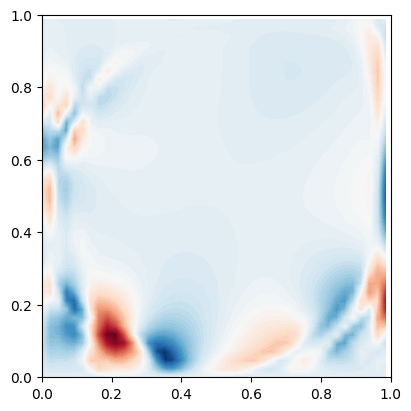

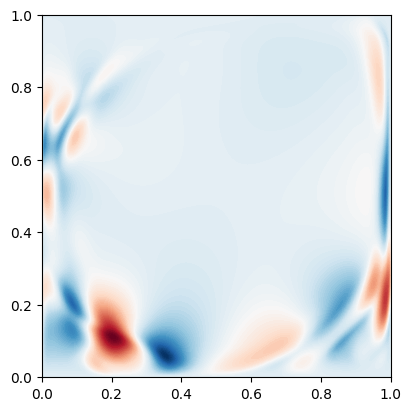

In [16]:
Q_true = input_dict['UV'][:, :, :] - input_dict['mean'][None, :]

error = np.linalg.norm(Q_true[:, :nx_t, :ny_t] - Q_rec) / np.linalg.norm(Q_true[:, :nx_t, :ny_t])
print(f"Relative error: {100*error:.4f}%")

xlim = (x_grid.min(), x_grid.max())
y_lim = (y_grid.min(), y_grid.max())
domain_aspect = (xlim[1]-xlim[0])/(y_lim[1]-y_lim[0])

fig_width = 4
fig_height = fig_width*domain_aspect

plt.figure(constrained_layout=True, figsize=(fig_width, fig_height))
plt.contourf(y_grid_t, x_grid_t, Q_rec[-1, :, :, 0], levels=100, cmap='RdBu_r')
plt.xlim(y_lim)
plt.ylim(xlim)
plt.show()

plt.figure(constrained_layout=True, figsize=(fig_width, fig_height))
plt.contourf(y_grid, x_grid, Q_true[-1, :, :, 0], levels=100, cmap='RdBu_r')
plt.xlim(y_lim)
plt.ylim(xlim)
plt.show()

In [ ]:
# modes_vec = dls.Modal_decomp(Q_true[0, :, :, 0], patch_size)
# x_grid = input_dict['x_grid'][:patch_size, :patch_size]
# y_grid = input_dict['y_grid'][:patch_size, :patch_size]

# nskip = (patch_size - 1) // 2
# nskip_sample = patch_size - 1
# mid_pt = 1 + nskip_sample // 2

# dof_node = num_modes + 1
# dof_elem = 4 * dof_node

# modes_grid = np.zeros((patch_size, patch_size, num_modes))
# for i in range(num_modes):
#     modes_grid[:, :, i] = modes_vec[0][:, i].reshape(patch_size, patch_size, order='F')

# # adopted nodal order
# gfem_nodal_order = [1, 2, 3, 4]
# diag_opp_indx =    [3, 4, 1, 2]

# # Mode grid components for the four quadrants
# F_indx = [1, 2, 3, 4]  # faces order, F1:x-ve, F2:x+ve, F3:y-ve, F4:y+ve
# F1 = list(range(0, mid_pt))
# F2 = list(range(mid_pt - 1, patch_size))
# F3 = list(range(0, mid_pt))
# F4 = list(range(mid_pt - 1, patch_size))

# indices = [
#     (F1, F4), # 1
#     (F2, F4), # 2
#     (F2, F3), # 3
#     (F1, F3), # 4
# ]

# modes_grid_1_comp = np.zeros((mid_pt, mid_pt, num_modes))
# modes_grid_2_comp = np.zeros((mid_pt, mid_pt, num_modes))
# modes_grid_3_comp = np.zeros((mid_pt, mid_pt, num_modes))
# modes_grid_4_comp = np.zeros((mid_pt, mid_pt, num_modes))

# comp1_x, comp1_y = np.meshgrid(F1, F4, indexing='ij')
# comp2_x, comp2_y = np.meshgrid(F2, F4, indexing='ij')
# comp3_x, comp3_y = np.meshgrid(F2, F3, indexing='ij')
# comp4_x, comp4_y = np.meshgrid(F1, F3, indexing='ij')

# for i in range(num_modes):
#     modes_grid_1_comp[:,:, i] = modes_grid[comp1_x, comp1_y, i]
#     modes_grid_2_comp[:,:, i] = modes_grid[comp2_x, comp2_y, i]
#     modes_grid_3_comp[:,:, i] = modes_grid[comp3_x, comp3_y, i]
#     modes_grid_4_comp[:,:, i] = modes_grid[comp4_x, comp4_y, i]


# modes_vec_comp1 = modes_grid_1_comp.reshape(mid_pt**2, num_modes, order='F')
# modes_vec_comp2 = modes_grid_2_comp.reshape(mid_pt**2, num_modes, order='F')
# modes_vec_comp3 = modes_grid_3_comp.reshape(mid_pt**2, num_modes, order='F')
# modes_vec_comp4 = modes_grid_4_comp.reshape(mid_pt**2, num_modes, order='F')


# # local modal matrix for single element
# i, j = 1, 1

# x1 = x_grid[ i   *nskip,  (j-1)*nskip]
# x2 = x_grid[ i   *nskip,   j   *nskip]
# x3 = x_grid[(i-1)*nskip,   j   *nskip]
# x4 = x_grid[(i-1)*nskip,  (j-1)*nskip]

# y1 = y_grid[ i   *nskip,  (j-1)*nskip]
# y2 = y_grid[ i   *nskip,   j   *nskip]
# y3 = y_grid[(i-1)*nskip,   j   *nskip]
# y4 = y_grid[(i-1)*nskip,  (j-1)*nskip]

# xpt = [x1, x2, x3, x4]
# ypt = [y1, y2, y3, y4]

# N1 = np.zeros(((nskip+1)**2))
# N2 = np.zeros(((nskip+1)**2))
# N3 = np.zeros(((nskip+1)**2))
# N4 = np.zeros(((nskip+1)**2))

# for kx in range((nskip+1)):
    
#     for ky in range((nskip+1)):
        
#         x_val = x_grid[kx, ky]
#         y_val = y_grid[kx, ky]
#         iind = ky*(nskip+1) + kx
#         N = dls.FEM_shape_calculator_ortho_gfemlr(x_val, y_val, xpt, ypt)
#         N1[iind] = N[0][0]
#         N2[iind] = N[1][0]
#         N3[iind] = N[2][0]
#         N4[iind] = N[3][0]

# modemat_local = np.hstack([
#     N1[:, np.newaxis],
#     N1[:, np.newaxis] * modes_vec_comp3,
#     N2[:, np.newaxis],
#     N2[:, np.newaxis] * modes_vec_comp4,
#     N3[:, np.newaxis],
#     N3[:, np.newaxis] * modes_vec_comp1,
#     N4[:, np.newaxis],
#     N4[:, np.newaxis] * modes_vec_comp2
# ])

# Wt_vec = dls._build_wt_vec(nskip)

# modemat_local_wt = modemat_local.copy()
# for kk in range(dof_elem):
#     modemat_local_wt[:, kk] *= Wt_vec

: 

: 

: 

: 

In [ ]:
# plt.figure()
# plt.imshow(modemat_local[:, 2].reshape(mid_pt, mid_pt, order='F'), origin='lower', cmap='RdBu_r')

: 

: 

: 

: 

In [ ]:
# lltogl = dls.build_lltogl(i=0, j=0, ny_g = latent_config.ny_g, dof_node=dof_node, IJK=dls.node_map())

: 

: 

: 

: 

In [ ]:
# snap_start = 0
# snap_end = 1

# dof_u_arr = dof_u
# dof_v_arr = dof_v
# dof_local_u = dof_u_arr[snap_start:snap_end, :][:, lltogl].T
# dof_local_v = dof_v_arr[snap_start:snap_end, :][:, lltogl].T

# dof_local_u = np.zeros((dof_elem, snap_end - snap_start))
# dof_local_v = np.zeros((dof_elem, snap_end - snap_start))

# Q_local_u_vec = latent_config.modemat_local_u @ dof_local_u
# Q_local_v_vec = latent_config.modemat_local_v @ dof_local_v

# Q_local_u = Q_local_u_vec.reshape((nskip + 1, nskip + 1, snap_end - snap_start), order="F")
# Q_local_v = Q_local_v_vec.reshape((nskip + 1, nskip + 1, snap_end - snap_start), order="F")

: 

: 

: 

: 

NameError: name 'Q_local_u' is not defined

<Figure size 640x480 with 0 Axes>

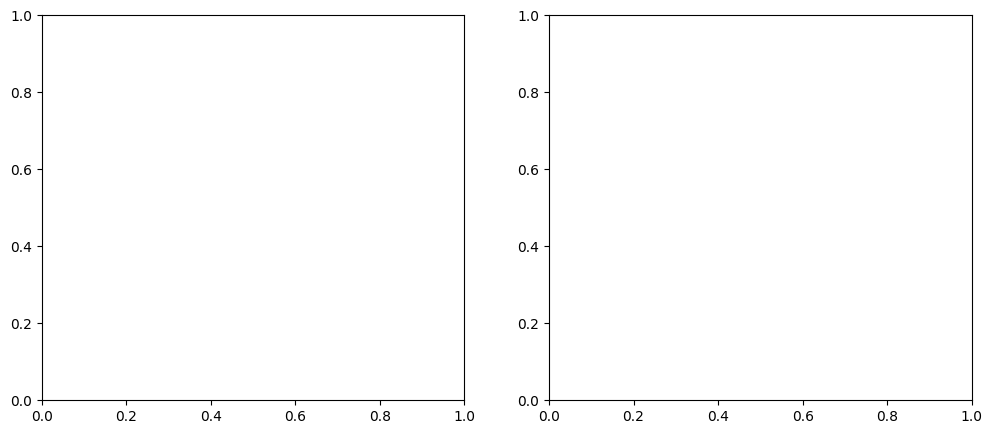

: 

: 

: 

: 

In [ ]:
plt.figure()
plt.subplots(1, 2, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(Q_local_u[:, :, 0], origin='lower', cmap='RdBu_r')
plt.subplot(1, 2, 2)
plt.imshow(modemat_local[:, 1].reshape(mid_pt, mid_pt, order='F'), origin='lower', cmap='RdBu_r')
plt.show()